In [1]:
print("Inside the Modeling notebook")

Inside the Modeling notebook


Imports

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from src.data_cleaning import full_clean_pipeline
from src.feature_engineering import (
    separate_target,
    get_feature_types,
    split_data
)

from src.modeling import (
    build_preprocessor,
    build_simple_logistic,
    build_balanced_logistic,
    build_l1_balanced_logistic,
    build_decision_tree,
    build_random_forest,
    build_gradient_boosting,
    train_pipeline,
    extract_feature_importance
)

sns.set(style="whitegrid")

Load & Split Data

In [3]:
df = full_clean_pipeline("../data/raw/hris_extract.csv")

X, y = separate_target(df)

categorical_cols, numeric_cols = get_feature_types(X)

X_train, X_test, y_train, y_test = split_data(X, y)

Evaluation Function

In [4]:
def evaluate(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Model 1 — Simple Logistic

ROC-AUC: 0.8022224136445861

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.72      0.38      0.50        47

    accuracy                           0.88       294
   macro avg       0.81      0.68      0.72       294
weighted avg       0.86      0.88      0.86       294



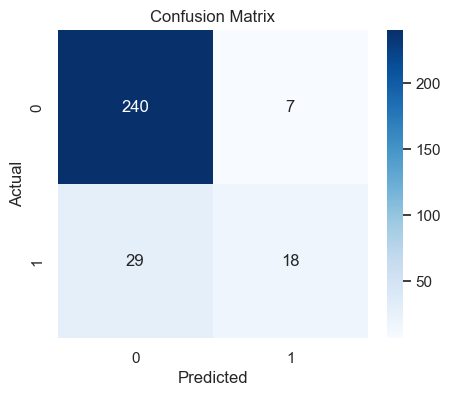

In [5]:
preprocessor_scaled = build_preprocessor(categorical_cols, numeric_cols, scale_numeric=True)

simple_model = build_simple_logistic()

simple_pipeline = train_pipeline(simple_model, preprocessor_scaled, X_train, y_train)

simple_metrics = evaluate(simple_pipeline, X_test, y_test)
simple_metrics

Extract Important Features

In [6]:
importance_df = extract_feature_importance(
    simple_pipeline,
    categorical_cols,
    numeric_cols
)

importance_df.head(10)

,Feature,Importance
20,OverTime_Yes,1.852542
0,BusinessTravel_Travel_Frequently,1.652326
11,JobRole_Laboratory Technician,1.187167
17,JobRole_Sales Representative,1.002005
19,MaritalStatus_Single,0.864701
1,BusinessTravel_Travel_Rarely,0.776823
10,JobRole_Human Resources,0.586681
42,YearsSinceLastPromotion,0.517623
32,NumCompaniesWorked,0.449936
40,YearsAtCompany,0.402445


Model 2 — Balanced Logistic

ROC-AUC: 0.802739254027048

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294



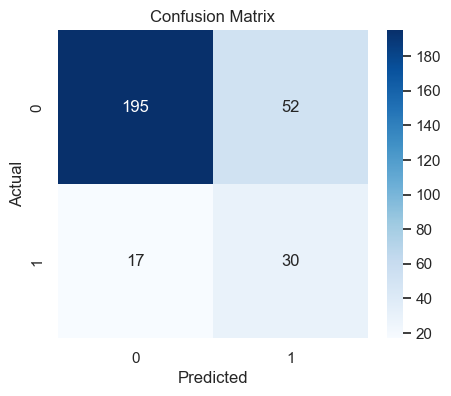

In [7]:
balanced_model = build_balanced_logistic()

balanced_pipeline = train_pipeline(balanced_model, preprocessor_scaled, X_train, y_train)

balanced_metrics = evaluate(balanced_pipeline, X_test, y_test)
balanced_metrics

Extract Important Features

In [8]:
importance_df = extract_feature_importance(
    balanced_pipeline,
    categorical_cols,
    numeric_cols
)

importance_df.head(10)

,Feature,Importance
0,BusinessTravel_Travel_Frequently,1.733054
20,OverTime_Yes,1.695355
11,JobRole_Laboratory Technician,1.507418
17,JobRole_Sales Representative,1.463819
19,MaritalStatus_Single,1.122494
1,BusinessTravel_Travel_Rarely,1.001151
10,JobRole_Human Resources,0.844987
40,YearsAtCompany,0.662279
18,MaritalStatus_Married,0.509310
15,JobRole_Research Scientist,0.498029


MODEL 3 — L1 Balanced Logistic

ROC-AUC: 0.8017917133258678

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.85       247
           1       0.38      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.83      0.77      0.79       294



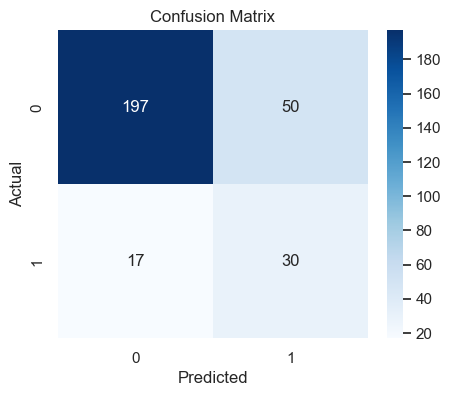

In [9]:
l1_model = build_l1_balanced_logistic()

l1_pipeline = train_pipeline(l1_model, preprocessor_scaled, X_train, y_train)

l1_metrics = evaluate(l1_pipeline, X_test, y_test)
l1_metrics

Extract Important Features

In [10]:
importance_df = extract_feature_importance(
    l1_pipeline,
    categorical_cols,
    numeric_cols
)

importance_df.head(10)

,Feature,Importance
20,OverTime_Yes,1.682661
0,BusinessTravel_Travel_Frequently,1.675728
11,JobRole_Laboratory Technician,1.323192
19,MaritalStatus_Single,1.056181
17,JobRole_Sales Representative,1.026042
1,BusinessTravel_Travel_Rarely,0.942017
40,YearsAtCompany,0.621304
18,MaritalStatus_Married,0.445403
8,EducationField_Technical Degree,0.425514
42,YearsSinceLastPromotion,0.422653


##### Modeling Summary

Three logistic regression models were evaluated to predict attrition. All models achieved strong discriminative performance (ROC-AUC ≈ 0.80). However, the baseline model underperformed in identifying leavers due to class imbalance.

Applying class weighting significantly improved recall for attrition (from 38% to 64%), making the balanced and L1-regularized models more suitable for business use.

The L1-regularized model confirmed that the strongest drivers increasing attrition risk are:

* Overtime

* Frequent business travel

* Single marital status

* Are high performers

* Certain operational job roles

Protective factors include:

* R&D department

* Higher job and environment satisfaction

* Longer tenure in role and with current manager

* Greater overall experience

Overall, attrition is structurally driven by workload intensity, mobility factors, and engagement levels, making it predictable and actionable through targeted retention strategies.

MODEL 4 — Decision Tree

ROC-AUC: 0.6534585235593074

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       247
           1       0.25      0.45      0.32        47

    accuracy                           0.70       294
   macro avg       0.56      0.60      0.57       294
weighted avg       0.78      0.70      0.73       294



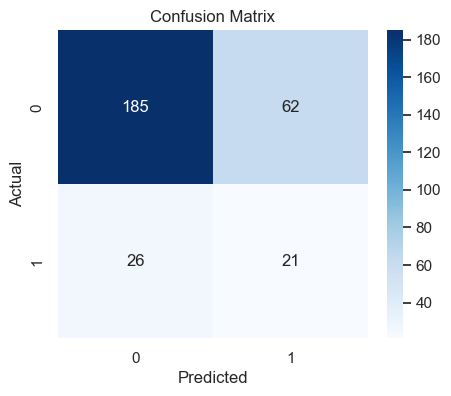

In [11]:
preprocessor_tree = build_preprocessor(categorical_cols, numeric_cols, scale_numeric=False)

tree_model = build_decision_tree()

tree_pipeline = train_pipeline(tree_model, preprocessor_tree, X_train, y_train)

tree_metrics = evaluate(tree_pipeline, X_test, y_test)
tree_metrics

Extract Important Features

In [12]:
importance_df = extract_feature_importance(
    tree_pipeline,
    categorical_cols,
    numeric_cols
)

importance_df.head(10)

,Feature,Importance
30,MonthlyIncome,0.214188
36,StockOptionLevel,0.156478
20,OverTime_Yes,0.152239
43,YearsWithCurrManager,0.078387
16,JobRole_Sales Executive,0.044877
22,DailyRate,0.038611
21,Age,0.038468
8,EducationField_Technical Degree,0.036993
23,DistanceFromHome,0.034629
32,NumCompaniesWorked,0.031195


Decision Tree Model Summary
Performance

* ROC-AUC: 0.65 (lower than logistic regression ~0.80)

* Recall (Attrition): 45%

* Accuracy: 70%

Interpretation:

* The tree captures some attrition patterns but performs worse than logistic regression.

* AUC dropped significantly (0.80 → 0.65).

* Recall is lower than balanced logistic (64%).

Conclusion: A single decision tree is unstable and underperforms.

MODEL 5 — Random Forest

ROC-AUC: 0.7138427082436041

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89       247
           1       0.41      0.38      0.40        47

    accuracy                           0.81       294
   macro avg       0.65      0.64      0.64       294
weighted avg       0.81      0.81      0.81       294



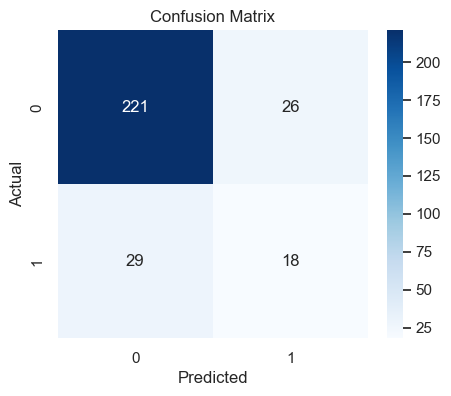

In [13]:
rf_model = build_random_forest()

rf_pipeline = train_pipeline(rf_model, preprocessor_tree, X_train, y_train)

rf_metrics = evaluate(rf_pipeline, X_test, y_test)
rf_metrics

Extract Important Features

In [14]:
importance_df = extract_feature_importance(
    rf_pipeline,
    categorical_cols,
    numeric_cols
)

importance_df.head(10)

,Feature,Importance
30,MonthlyIncome,0.090194
20,OverTime_Yes,0.080512
37,TotalWorkingYears,0.070795
40,YearsAtCompany,0.067018
21,Age,0.065974
43,YearsWithCurrManager,0.054232
36,StockOptionLevel,0.046077
22,DailyRate,0.041859
28,JobLevel,0.040617
41,YearsInCurrentRole,0.037048


Random Forest Model Summary

Performance:

* ROC-AUC: 0.71

* Recall (Attrition): 38%

* Accuracy: 81%

Interpretation:

* Random Forest performs better than a single tree, but

* It underperforms compared to balanced logistic regression (AUC ~0.80, Recall 64%)

* Recall dropped significantly compared to balanced logistic

In this dataset, linear modeling is outperforming ensemble trees.

MODEL 6 — Gradient Boosting

ROC-AUC: 0.7625979843225085

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.48      0.21      0.29        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.60       294
weighted avg       0.80      0.84      0.81       294



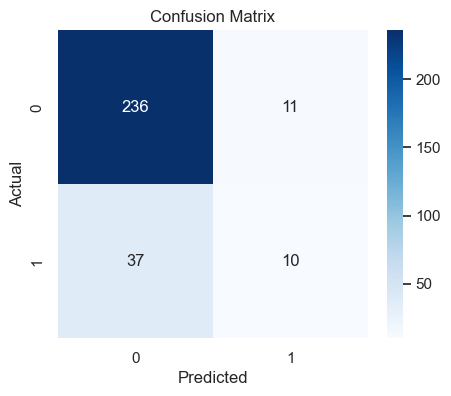

In [15]:
gb_model = build_gradient_boosting()

gb_pipeline = train_pipeline(gb_model, preprocessor_tree, X_train, y_train)

gb_metrics = evaluate(gb_pipeline, X_test, y_test)
gb_metrics

Extract Important Features

In [16]:
importance_df = extract_feature_importance(
    gb_pipeline,
    categorical_cols,
    numeric_cols
)

importance_df.head(10)

,Feature,Importance
30,MonthlyIncome,0.136124
21,Age,0.095085
20,OverTime_Yes,0.088673
37,TotalWorkingYears,0.057725
22,DailyRate,0.057254
43,YearsWithCurrManager,0.049112
36,StockOptionLevel,0.046166
26,HourlyRate,0.045652
23,DistanceFromHome,0.039253
25,EnvironmentSatisfaction,0.037516


Gradient Boosting Summary

* ROC-AUC improved over Random Forest (0.76 vs 0.71)

* But recall dropped sharply (21%)

* Model favors predicting non-attrition

Feature importance again confirms:

* MonthlyIncome

* Age

* OverTime

* TotalWorkingYears

* YearsWithCurrManager

* StockOptionLevel

These are consistent structural drivers.

##### Final Model Summary:

| Model             | ROC-AUC | Recall (Attrition) | Accuracy | Interpretation               |
| ----------------- | ------- | ------------------ | -------- | ---------------------------- |
| Baseline Logistic | 0.80    | 38%                | 88%      | Biased toward majority       |
| Balanced Logistic | 0.80    | 64%                | 77%      | Strong recall improvement    |
| L1 Logistic       | 0.80    | 64%                | 77%      | Best balance + interpretable |
| Decision Tree     | 0.65    | 45%                | 70%      | Weak, unstable               |
| Random Forest     | 0.71    | 38%                | 81%      | Moderate                     |
| Gradient Boosting | 0.76    | 21%                | 84%      | Good AUC, poor recall        |


Multiple models were evaluated, including logistic regression, decision trees, random forest, and gradient boosting. Balanced L1-regularized logistic regression achieved the best overall performance (ROC-AUC ≈ 0.80) while identifying 64% of at-risk employees.

Tree-based ensemble methods did not materially outperform logistic regression and demonstrated lower recall for attrition. Across all models, overtime, compensation level, tenure stability, managerial continuity, and engagement metrics consistently emerged as the strongest drivers.

Given its predictive strength, stability, and interpretability, the balanced L1 logistic regression model is recommended for retention risk scoring and executive decision support.